# 02 — Explore one light curve

Phase 1 limitations carried into Phase 2 planning:

1. **The flattener keeps detections only.** Non-detections and forced
   photometry from the ALeRCE response are dropped on the way to Parquet.
   This notebook makes that decision visible before we lock the Phase 2
   schema.
2. **Light-curve fetching is sequential.** Known scale issue for the
   eventual 60-day training pull. Not fixing now.
3. **Re-running on the same date overwrites prior pulls.** Known.
   Not fixing now.

Goal: pick one real object pulled in Phase 1, look at what the Parquet
shows, look at what the raw JSON adds, decide what to keep.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from argus.config import LIGHTCURVES_DIR, RAW_DIR

pd.set_option("display.max_columns", 30)


In [2]:
parquet_files = sorted(LIGHTCURVES_DIR.glob("*.parquet"))
latest = parquet_files[-1]
date = latest.stem
df = pd.read_parquet(latest)
print(f"loaded {latest.name}: {len(df)} detection rows, {df['oid'].nunique()} objects")
df.head(3)


loaded 2026-05-20.parquet: 1418 detection rows, 89 objects


,oid,candid,mjd,fid,magpsf,sigmapsf,magap,sigmagap,diffmaglim,rb,drb,isdiffpos,ra,dec,obj_ndet,obj_firstmjd,obj_lastmjd,obj_meanra,obj_meandec,obj_class,obj_classifier,obj_probability
0,ZTF18acazegl,1257293980215015015,59011.293981,1,17.716228,0.078651,17.9285,0.0670,20.064907,0.744286,0.867934,1,265.388175,-20.127867,12,59011.293981,61180.374699,265.388195,-20.127837,None,None,None
1,ZTF18acazegl,1685171990215015010,59439.171991,1,17.989717,0.161556,18.0290,0.1001,19.506445,0.554286,0.989695,1,265.388162,-20.127930,12,59011.293981,61180.374699,265.388195,-20.127837,None,None,None
2,ZTF18acazegl,2637504580215010020,60391.504583,1,17.933052,0.135770,18.3785,0.1365,19.295412,0.655714,0.998998,-1,265.388383,-20.127934,12,59011.293981,61180.374699,265.388195,-20.127837,None,None,None


In [3]:
# Inventory what sections of the raw lightcurve responses we actually got
raw_lc_dir = RAW_DIR / date / "lightcurves"
raw_files = sorted(raw_lc_dir.glob("*.json"))
print(f"raw JSON files on disk for {date}: {len(raw_files)}")

section_objects = {"detections": 0, "non_detections": 0, "forced_photometry": 0}
section_rows = {k: 0 for k in section_objects}
for p in raw_files:
    raw = json.loads(p.read_text())
    for k in section_objects:
        v = raw.get(k)
        if isinstance(v, list) and len(v) > 0:
            section_objects[k] += 1
            section_rows[k] += len(v)

print("\nObjects with each section non-empty (out of all raw files):")
for k in section_objects:
    print(f"  {k:20s}  {section_objects[k]:>4d} objects, {section_rows[k]:>6d} total rows")


raw JSON files on disk for 2026-05-20: 100

Objects with each section non-empty (out of all raw files):
  detections             100 objects,   2191 total rows
  non_detections         100 objects,  19493 total rows
  forced_photometry        0 objects,      0 total rows


In [4]:
# Pick object with most detections AND detections in both g and r
per_oid = df.groupby("oid")["fid"].nunique()
both_filters = per_oid[per_oid >= 2].index
if len(both_filters) == 0:
    raise RuntimeError("No objects in latest parquet have detections in both g and r — widen the pull.")
candidates = df[df["oid"].isin(both_filters)]
oid_counts = candidates.groupby("oid").size().sort_values(ascending=False)
oid = oid_counts.index[0]
print(f"selected: {oid}  ({oid_counts.iloc[0]} detections across both filters)")
obj_df = df[df["oid"] == oid].sort_values("mjd")
obj_df[["mjd", "fid", "magpsf", "sigmapsf", "rb"]].head()


selected: ZTF18abujsbq  (147 detections across both filters)


,mjd,fid,magpsf,sigmapsf,rb
1271,58370.147917,2,19.370323,0.107989,0.813333
1272,58428.101655,2,19.407467,0.165007,0.800000
1273,59366.393067,2,19.635496,0.140357,0.855714
1274,59381.393206,2,19.321503,0.187374,0.857143
1275,59440.249294,2,20.047417,0.212888,0.671429


## (a) Parquet view — detections only, with error bars

What the autoencoder would currently see.


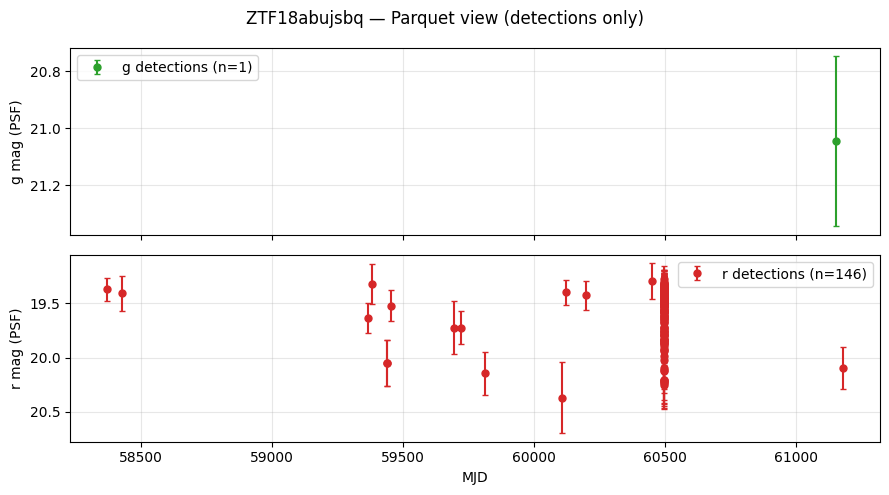

In [5]:
FID = {1: ("g", "C2"), 2: ("r", "C3")}
PLOT_DIR = Path("_plots")
PLOT_DIR.mkdir(exist_ok=True)

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
for ax, fid in zip(axes, [1, 2]):
    sub = obj_df[obj_df["fid"] == fid]
    label, color = FID[fid]
    if len(sub):
        ax.errorbar(sub["mjd"], sub["magpsf"], yerr=sub["sigmapsf"],
                    fmt="o", color=color, capsize=2, markersize=5,
                    label=f"{label} detections (n={len(sub)})")
    ax.invert_yaxis()
    ax.set_ylabel(f"{label} mag (PSF)")
    ax.grid(alpha=0.3)
    ax.legend(loc="best")
axes[-1].set_xlabel("MJD")
fig.suptitle(f"{oid} — Parquet view (detections only)")
fig.tight_layout()
fig.savefig(PLOT_DIR / "plot_a_parquet.png", dpi=110, bbox_inches="tight")
plt.show()


## (b) Full raw view — detections + non-detections + forced photometry

Same axes. Non-detections plotted as 5σ upper limits at `diffmaglim`
(downward triangles). Forced photometry as small grey dots.


raw counts for ZTF18abujsbq: det=150, non_det=674, forced_phot=0


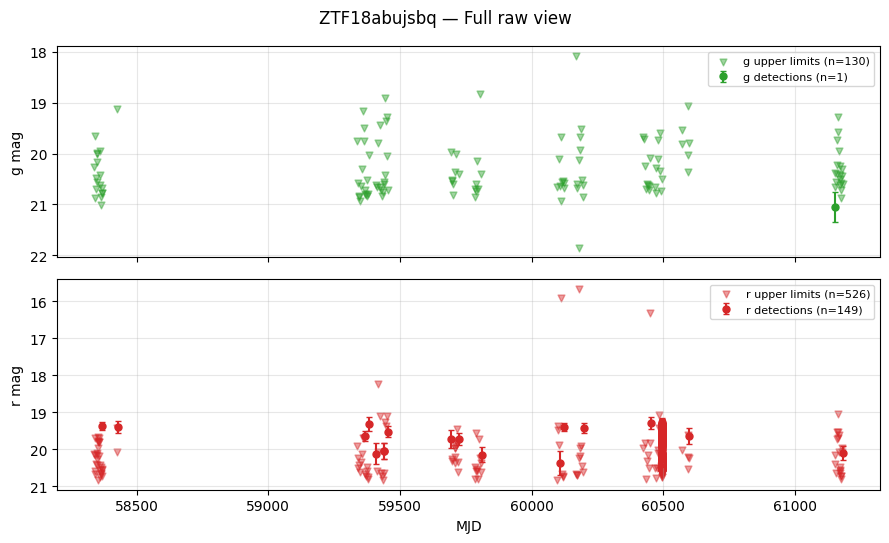

In [6]:
raw = json.loads((raw_lc_dir / f"{oid}.json").read_text())
det = pd.DataFrame(raw.get("detections") or [])
nondet = pd.DataFrame(raw.get("non_detections") or [])
fp = pd.DataFrame(raw.get("forced_photometry") or [])
print(f"raw counts for {oid}: det={len(det)}, non_det={len(nondet)}, forced_phot={len(fp)}")

fig, axes = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)
for ax, fid in zip(axes, [1, 2]):
    label, color = FID[fid]
    if len(det) and "fid" in det.columns:
        d = det[det["fid"] == fid]
        if len(d):
            ax.errorbar(d["mjd"], d["magpsf"], yerr=d["sigmapsf"],
                        fmt="o", color=color, capsize=2, markersize=5, zorder=3,
                        label=f"{label} detections (n={len(d)})")
    if len(nondet) and "fid" in nondet.columns:
        n = nondet[nondet["fid"] == fid]
        if len(n):
            ax.scatter(n["mjd"], n["diffmaglim"], marker="v", s=24,
                       color=color, alpha=0.45, zorder=1,
                       label=f"{label} upper limits (n={len(n)})")
    if len(fp) and "fid" in fp.columns:
        f_ = fp[fp["fid"] == fid]
        mag_col = next((c for c in ("mag", "magpsf", "mag_corr") if c in f_.columns), None)
        if len(f_) and mag_col:
            ax.scatter(f_["mjd"], f_[mag_col], marker=".", s=10, color="gray",
                       alpha=0.5, zorder=2,
                       label=f"{label} forced phot (n={len(f_)})")
    ax.invert_yaxis()
    ax.set_ylabel(f"{label} mag")
    ax.grid(alpha=0.3)
    ax.legend(loc="best", fontsize=8)
axes[-1].set_xlabel("MJD")
fig.suptitle(f"{oid} — Full raw view")
fig.tight_layout()
fig.savefig(PLOT_DIR / "plot_b_raw.png", dpi=110, bbox_inches="tight")
plt.show()


## (c) Difference — what we lost for this specific object


In [7]:
det_count, nondet_count, fp_count = len(det), len(nondet), len(fp)

def _span(df_, col):
    if not len(df_) or col not in df_.columns:
        return None, None
    return float(df_[col].min()), float(df_[col].max())

det_min, det_max = _span(det, "mjd")
non_min, non_max = _span(nondet, "mjd")
fp_min, fp_max = _span(fp, "mjd")

lines = [
    f"For **{oid}**, Parquet kept **{det_count} detection rows**. "
    f"The raw JSON also contains **{nondet_count} non-detections** and "
    f"**{fp_count} forced-photometry points** that the flattener dropped.",
    "",
]
if non_min is not None and det_min is not None:
    if non_min < det_min:
        lines.append(
            f"Non-detections extend coverage **backwards in time**: earliest "
            f"detection is at MJD {det_min:.2f}, but ZTF was already pointing "
            f"at this field at MJD {non_min:.2f} — that's "
            f"**~{det_min - non_min:.0f} days of \"looked and didn't see it above the limit\"** "
            f"that constrains the rise rate."
        )
        lines.append("")
    elif non_max > det_max:
        lines.append(
            f"Non-detections extend coverage **forwards in time** past the last "
            f"detection by ~{non_max - det_max:.0f} days — those are upper limits "
            f"on the fading source."
        )
        lines.append("")
if fp_count > 0:
    lines.append(
        f"Forced photometry adds {fp_count} flux measurements at the object's "
        "location regardless of detection significance — this fills gaps in the "
        "alert-based light curve, especially for faint or slowly varying sources."
    )
else:
    lines.append(
        "Forced photometry is empty for this object — that's normal; it's only "
        "populated for some ALeRCE objects."
    )

display(Markdown("\n".join(lines)))


For **ZTF18abujsbq**, Parquet kept **150 detection rows**. The raw JSON also contains **674 non-detections** and **0 forced-photometry points** that the flattener dropped.

Non-detections extend coverage **backwards in time**: earliest detection is at MJD 58370.15, but ZTF was already pointing at this field at MJD 58340.30 — that's **~30 days of "looked and didn't see it above the limit"** that constrains the rise rate.

Forced photometry is empty for this object — that's normal; it's only populated for some ALeRCE objects.

## Phase 2 schema decisions

Decisions to lock before any model code, with my recommendation on each.

### 1. What goes into the input: detections only, +non-detections, or +forced photometry?

- **Detections only** — cleanest, smallest, but the model can't tell "we looked and the source wasn't there" from "we didn't look."
- **+ Non-detections (upper limits)** — adds temporal coverage. Pre-rise non-detections constrain rise rate; gaps in non-detections constrain fading. High-signal for anomaly detection.
- **+ Forced photometry** — flux at the object's location regardless of detection. Quality varies; not always populated; different error profile.

**Recommendation: detections + non-detections.** Skip forced photometry for the first autoencoder. It can come in as a Phase 2.5 add-on without changing the architecture (just more rows in the same shape).

### 2. Magnitude vs flux

- **Magnitudes** are log-scale with asymmetric errors (±0.1 mag means different absolute changes at 17 vs 20). Non-detections have no defined magnitude — only `diffmaglim`.
- **Flux** is linear, symmetric errors, well-defined for non-detections (≈ 0 ± noise-from-limit), and lets a single MSE-style reconstruction loss behave sensibly.

**Recommendation: flux.** Convert via `flux = 10**(-0.4 * (mag - zp))` with `zp = 23.9` (flux in μJy). Convert upper limits the same way and treat as `flux = 0` with noise derived from `diffmaglim`. Standard choice in transient ML (cf. PLAsTiCC, ParSNIP).

### 3a. Cadence handling: fixed grid vs irregular

ZTF cadence is shaped by survey strategy, weather, and seasonal visibility. Weeks-long gaps are common; intra-night sampling is rare.

- **Resample to fixed grid** — required for a vanilla 1D CNN. Forces a binning choice; a mask channel is the honest way to handle "no observation."
- **Leave irregular** — needs a model that consumes timestamps natively (GP extractor, transformer with time embeddings).

**Recommendation: bin to a fixed 1-day grid with a mask channel.** Each input becomes `(T, channels)` where channels = `[g_flux, g_err, g_mask, r_flux, r_err, r_mask]`. Mask = 1 where we have a real observation (detection or upper limit), 0 where we don't. No imputation.

### 3b. Model architecture: 1D CNN vs transformer vs GP feature extractor

- **1D CNN encoder-decoder** — simple, fast, debuggable. Translation-equivariant in time. Learned kernels are inspectable; reconstruction error is straightforward to attribute. Trains in minutes on a laptop or Colab T4.
- **Transformer with time embeddings** (ParSNIP-style with learned positional encoding from MJD) — handles long-range dependencies and irregular timestamps natively. Costs more data, more compute, more tuning, less interpretability.
- **GP feature extractor** (PLAsTiCC/RAPID-style) — fit a Gaussian process per object, feed GP-derived smooth features into a smaller downstream model. Strong astronomical inductive bias.

**Recommendation: 1D CNN.** Two reasons. (1) Simpler and easier to debug for an exploratory project where the story is the insight, not the model — kernels are inspectable, training is minutes not hours, and the eventual talk is much easier to give. (2) The GP extractor has a specific failure mode *for this project*: it imposes a smoothness prior on the light curve before the autoencoder sees it. Anomalous objects can violate that prior — and "anomalous" is exactly what we want to find. Pre-smoothing with a GP risks pre-filtering the anomalies. The transformer is reasonable but is overkill until there's evidence the CNN can't capture what we need.

### 4. Per-filter structure

- **One channel per filter** — g and r as separate channels in the CNN; the model learns cross-filter color via cross-channel kernels.
- **Interleaved** — one sequence with `fid` as a categorical input.

**Recommendation: one channel per filter (with its own mask).** g–r color is one of the most diagnostic features in transient typing; we want the model to access it natively. Interleaving treats g and r as equivalent in the time axis, which is wrong.

### 5. Fixed-length window vs variable-length

ZTF objects have between weeks and years of history. Most interesting transient evolution is day-to-month.

- **Fixed-length** — required for a vanilla CNN autoencoder.
- **Variable-length** — masking + attention or RNN.

**Recommendation: fixed-length, 200 days, right-aligned to the most recent detection.** Covers full SN Ia evolution (~100 days), most SLSNe (~300), flares (~days). Right-alignment means the model always sees "what just happened" in the recent bins — that's the operationally interesting region for live novelty detection. Pad mask=0 if history is shorter.

**Tradeoff being made explicit:** this window optimizes for *"what's new"* — recent, fast evolution — at the cost of *"what's strange on long baselines."* Quasi-periodic phenomena with multi-year periods, slowly drifting variables, decade-scale outbursts, anything where the anomaly is only visible across the full history will be invisible to Argus as scoped. Long-baseline anomaly detection would need a separate pipeline with a different windowing strategy (e.g., full-history features, periodogram-based features, or a much longer window with downsampling). Out of scope for Phase 2; flagged as a real blind spot.

### 6. Normalization

- **No normalization** — six orders of magnitude in flux. Bad.
- **Per-object min-max in flux** — destroys absolute brightness, emphasizes shape.
- **Per-object z-score in flux** — preserves sign (negative flux is meaningful in difference imaging).
- **Global standardization** — preserves absolute brightness, but dynamic range hurts capacity allocation.
- **Asinh-stretch** — `asinh(flux/softening)`, compresses bright values like log but is smooth through zero. Standard in astronomical imaging.

**Recommendation: asinh-stretch then per-object median-subtract.** Asinh compresses dynamic range without breaking on non-detections (`asinh(0) = 0`). Median-subtraction strips the per-object baseline so the loss responds to *shape*, not "this object is bright." Store the per-object median alongside the latent so we can recover absolute values when reporting findings to astronomers.

### 7. Empirical audit of reconstruction loss

Decisions 2, 3a, 4, 6 are all *intended* to push reconstruction error onto shape and away from brightness, color, and cadence density. They might not. Before we trust any anomaly ranking, we audit.

**Concrete check — controlled-variation probe.** Hold out ~50 light curves the model never trained on. For each, synthesize four variants that change exactly one dimension:

1. **Brightness** — multiply all flux values by 0.5× and 2×. Shape unchanged.
2. **Color** — scale g and r flux by *different* factors. Cross-filter ratio shifted; per-filter shape preserved.
3. **Cadence density** — randomly mask 50% of real observations. Shape sampled more sparsely; underlying physical behavior unchanged.
4. **Shape** — inject a localized perturbation (e.g., a 10-day Gaussian flux bump) or warp the time axis.

Run the trained autoencoder on the original and each variant. Compute reconstruction loss per variant per object.

**Pass condition:** shape variants produce loss significantly larger than brightness, color, or cadence-density variants. If brightness or color variants score near the shape variants, normalization (Decision 6) isn't doing its job. If cadence-density variants dominate, the mask channel (Decision 3a) isn't being used properly.

**Complementary check — correlation on the training distribution.** Compute Spearman correlation between reconstruction loss and each of: per-object median flux, per-object g–r color, fraction of bins with mask=1. High correlation with any of those = the model is encoding that dimension instead of shape; the top-ranked "anomalies" will be biased toward bright objects, red objects, or well-covered objects rather than physically weird ones.

Both checks are cheap (no retraining, just inference) and let us catch a confused loss before we waste astronomer attention on rankings driven by the wrong signal.
